In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier # vecinos más cercanos para clasificación
from sklearn.metrics import accuracy_score # métrica de evaluación
from sklearn.metrics import classification_report

# Análisis Exploratorio

In [3]:
df_smokers = pd.read_csv('https://raw.githubusercontent.com/pokengineer/DataScience/main/datasets/smokers.csv')
df_smokers.head(5)

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
0,35,170,85,97.0,0.9,0.9,1,1,118,78,...,70,142,19.8,1,1.0,61,115,125,1,1
1,20,175,110,110.0,0.7,0.9,1,1,119,79,...,71,114,15.9,1,1.1,19,25,30,1,0
2,45,155,65,86.0,0.9,0.9,1,1,110,80,...,57,112,13.7,3,0.6,1090,1400,276,0,0
3,45,165,80,94.0,0.8,0.7,1,1,158,88,...,46,91,16.9,1,0.9,32,36,36,0,0
4,20,165,60,81.0,1.5,0.1,1,1,109,64,...,47,92,14.9,1,1.2,26,28,15,0,0


In [4]:
# verificamos los tipos de datos
df_smokers.dtypes

age                      int64
height(cm)               int64
weight(kg)               int64
waist(cm)              float64
eyesight(left)         float64
eyesight(right)        float64
hearing(left)            int64
hearing(right)           int64
systolic                 int64
relaxation               int64
fasting blood sugar      int64
Cholesterol              int64
triglyceride             int64
HDL                      int64
LDL                      int64
hemoglobin             float64
Urine protein            int64
serum creatinine       float64
AST                      int64
ALT                      int64
Gtp                      int64
dental caries            int64
smoking                  int64
dtype: object

In [5]:
print("Tamaño del dataframe : {}".format(df_smokers.shape))

Tamaño del dataframe : (38984, 23)


In [6]:
# Verificamos si hay valores nulos para imputar
df_smokers.isnull().sum()

age                    0
height(cm)             0
weight(kg)             0
waist(cm)              0
eyesight(left)         0
eyesight(right)        0
hearing(left)          0
hearing(right)         0
systolic               0
relaxation             0
fasting blood sugar    0
Cholesterol            0
triglyceride           0
HDL                    0
LDL                    0
hemoglobin             0
Urine protein          0
serum creatinine       0
AST                    0
ALT                    0
Gtp                    0
dental caries          0
smoking                0
dtype: int64

smoking
0    24666
1    14318
Name: count, dtype: int64


<Axes: xlabel='smoking', ylabel='count'>

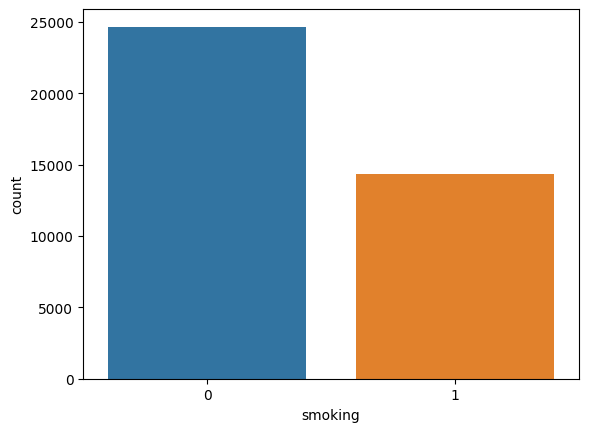

In [7]:
# Analisis de la distribución de la variable target "smoking"
print( df_smokers.smoking.value_counts() )
sns.countplot(x='smoking', data=df_smokers, hue='smoking', legend=False)

[]

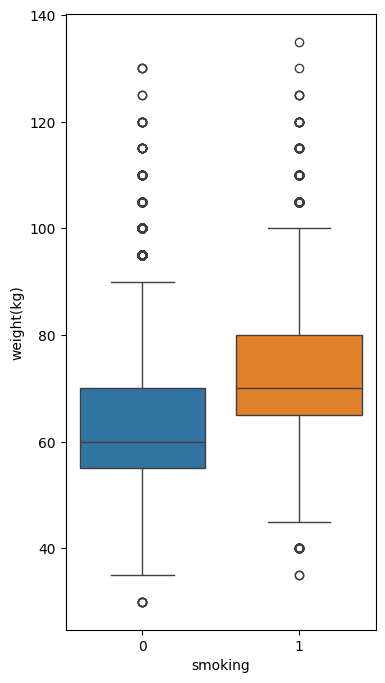

In [8]:
plt.figure(figsize=(4, 8))
s=sns.boxplot(x="smoking", y="weight(kg)", data=df_smokers, hue="smoking", legend=False)
s.plot()

# Correlación de Variables

<Axes: >

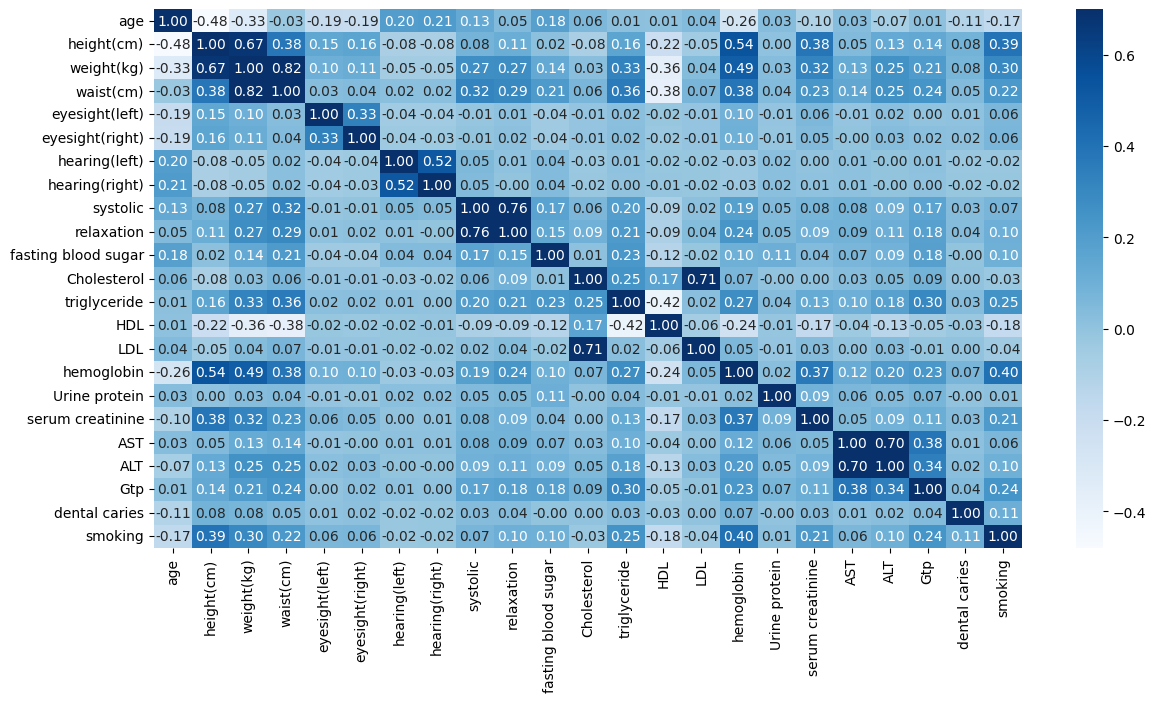

In [9]:
plt.figure(figsize=(14,7))
sns.heatmap(df_smokers.corr(), annot=True, vmax=.7, cmap ='Blues', fmt=".2f")

In [10]:
df_smokers_corr = df_smokers.corr()[["smoking"]]*100 # lo pasamos a porcentajes
df_smokers_corr = df_smokers_corr.drop("smoking", axis=0) # eliminamos la variable target
df_smokers_corr = df_smokers_corr.sort_values(["smoking"], ascending=False) # ordenamos en forma descendente
df_smokers_corr = abs(df_smokers_corr) # nos interesa el valor absouluto
df_smokers_corr

,smoking
hemoglobin,40.120561
height(cm),39.431445
weight(kg),29.934668
triglyceride,25.105661
Gtp,24.027443
waist(cm),22.335903
serum creatinine,21.247301
dental caries,10.760060
relaxation,10.366297
fasting blood sugar,9.990846


# Seleccionamos y Escalamos las variables que vamos a utilizar

In [11]:
# definimos df con las 10 columnas que elegimos para el modelo
# sería lo mismo que hacer un drop de las que no queremos
dfNUEVO = df_smokers[['hemoglobin', 'height(cm)', 'weight(kg)', 'triglyceride', 'Gtp',
       'waist(cm)', 'serum creatinine', 'dental caries', 'relaxation',
       'fasting blood sugar','smoking']]

In [12]:
# Hacemos el Split 70-30 para train-test
y_smokers = dfNUEVO["smoking"]
X_train, X_test, y_train, y_test = train_test_split(dfNUEVO.drop(["smoking"],axis = 1), y_smokers, test_size=0.3, stratify = y_smokers, random_state=42)

In [13]:
# usamos StandardScaler para escalar las variables
scaler_X = StandardScaler(with_mean=True, with_std=True)
scaler_X.fit(X_train) # entrenamos los valores quitandole la variable clase

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [14]:
X_train = scaler_X.transform(X_train)
X_test = scaler_X.transform(X_test)

In [15]:
test_scores = []

# Creamos y entrenamos el algoritmo con 20 valores de K
for k in range(3,40,2):
  knn = KNeighborsClassifier(k)
  knn.fit(X_train,y_train) # Creamos y entrenamos el clasificador knn

  # Para cada valor de K, evaluamos la capacidad de clasificación con datos de prueba
  y_pred = knn.predict(X_test)
  test_scores.append(accuracy_score(y_test, y_pred)) # Agregamos los K resultados de evaluación

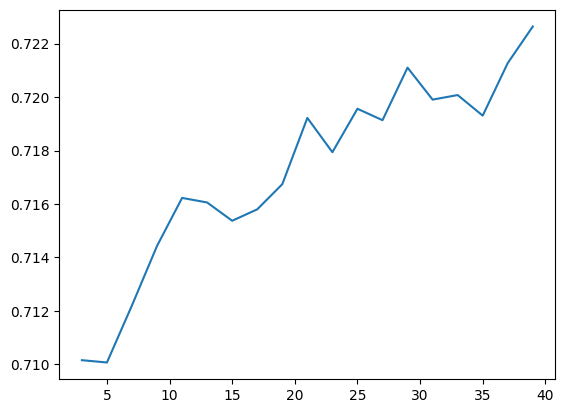

In [16]:
df_scores = pd.DataFrame([{"k":valor_k, "score":test_scores_k} for valor_k, test_scores_k in zip(range(3,40,2),test_scores)])
plt.plot(df_scores["k"], df_scores["score"])

In [17]:
df_scores

,k,score
0,3,0.710157
1,5,0.710072
2,7,0.712209
3,9,0.714432
4,11,0.716228
5,13,0.716057
6,15,0.715373
7,17,0.715800
8,19,0.716741
9,21,0.719220


In [18]:
# Entrenamos el algoritmo con el mejor K
knn = KNeighborsClassifier( 11 )
knn.fit(X_train,y_train) # Entrenamos el clasificador

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",11
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [19]:
y_pred_knn = knn.predict(X_test)

#Exactitud del modelo
print('Exactitud (accuracy) del modelo: {:.2f} %'.format(accuracy_score(y_test, y_pred_knn)*100))
print("-"*100)

# Reporte del clasificador
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_knn))

Exactitud (accuracy) del modelo: 71.62 %
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.77      0.78      0.78      7400
           1       0.62      0.61      0.61      4296

    accuracy                           0.72     11696
   macro avg       0.69      0.69      0.69     11696
weighted avg       0.72      0.72      0.72     11696



# Ejercicio
Dado el análisis exploratorio concluimos que no hace falta imputar variables y que la variable target esta balanceada.
- Usando el mapa de calor de correlaciones, ¿que pares de columnas comparten más de un 0.7 de correlación?
- Entrenar un modelo con K menor a 11, comparar los resultados
- Entrenar un modelo con K mayor a 11, comparar los resultados
- Entrenar un modelo con 3 variables, seleccionar un K apropiado y comparar los resultados
- Entrenar un modelo con todas las variables, seleccionar un K apropiado y comparar los resultados
- "Feature Engineering", Crear una columna nueva no redundante, entrenar un modelo y comparar los resultados

In [26]:
# Usando el mapa de calor de correlaciones, ¿que pares de columnas comparten más de un 0.7 de correlación?

# Find pairs with correlation > 0.7 (excluding self-correlation)
corr = dfNUEVO.corr()
pairs = []
cols = corr.columns
print(cols)
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        val = corr.iloc[i, j]
        if abs(val) >= 0.7:
            pairs.append((cols[i], cols[j], round(val, 3)))
print(pairs)
pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for p in pairs:
    print(f'{p[0]}  <-->  {p[1]}  :  {p[2]}')

Index(['hemoglobin', 'height(cm)', 'weight(kg)', 'triglyceride', 'Gtp',
       'waist(cm)', 'serum creatinine', 'dental caries', 'relaxation',
       'fasting blood sugar', 'smoking'],
      dtype='str')
[('height(cm)', 'weight(kg)', np.float64(0.674)), ('weight(kg)', 'waist(cm)', np.float64(0.825))]
weight(kg)  <-->  waist(cm)  :  0.825
height(cm)  <-->  weight(kg)  :  0.674


In [27]:
#Entrenar un modelo con K menor a 11, comparar los resultados
knn = KNeighborsClassifier( 5 )
knn.fit(X_train,y_train) # Entrenamos el clasificador
y_pred_knn = knn.predict(X_test)
#Exactitud del modelo
print('Exactitud (accuracy) del modelo: {:.2f} %'.format(accuracy_score(y_test, y_pred_knn)*100))
print("-"*100)
# Reporte del clasificador
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_knn))


Exactitud (accuracy) del modelo: 71.01 %
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.77      0.78      0.77      7400
           1       0.61      0.59      0.60      4296

    accuracy                           0.71     11696
   macro avg       0.69      0.68      0.69     11696
weighted avg       0.71      0.71      0.71     11696



In [32]:
#Entrenar un modelo con K mayor a 11, comparar los resultados
knn = KNeighborsClassifier( 15 )
knn.fit(X_train,y_train) # Entrenamos el clasificador
y_pred_knn = knn.predict(X_test)
#Exactitud del modelo
print('Exactitud (accuracy) del modelo: {:.2f} %'.format(accuracy_score(y_test, y_pred_knn)*100))
print("-"*100)
# Reporte del clasificador
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_knn))


Exactitud (accuracy) del modelo: 71.54 %
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.77      0.78      0.78      7400
           1       0.61      0.60      0.61      4296

    accuracy                           0.72     11696
   macro avg       0.69      0.69      0.69     11696
weighted avg       0.71      0.72      0.71     11696



In [47]:
#Entrenar un modelo con 3 variables, seleccionar un K apropiado y comparar los resultados
# usar sequential feature selection para elegir las 3 variables más importantes
from sklearn.feature_selection import SequentialFeatureSelector, f_classif
selector = SequentialFeatureSelector(estimator=KNeighborsClassifier(n_neighbors=11), n_features_to_select=3, scoring='accuracy', cv=5)
X_train_selected = selector.fit_transform(X_train, y_train)
# Obtener los nombres de las columnas seleccionadas (usar las 10 columnas originales de BASELINE_FEATURES)
selected_columns = selector.get_feature_names_out(input_features=BASELINE_FEATURES)
print("Columnas seleccionadas:", selected_columns)

# Transformar los datos de prueba
X_test_selected = selector.transform(X_test)

# Entrenar el modelo con las variables seleccionadas
knn = KNeighborsClassifier(n_neighbors=11)
knn.fit(X_train_selected, y_train) # Entrenamos el clasificador
y_pred_knn = knn.predict(X_test_selected)
#Exactitud del modelo
print('Exactitud (accuracy) del modelo: {:.2f} %'.format(accuracy_score(y_test, y_pred_knn)*100))
print("-"*100)
# Reporte del clasificador
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_knn))


Columnas seleccionadas: ['hemoglobin' 'height(cm)' 'Gtp']
Exactitud (accuracy) del modelo: 71.26 %
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.77      0.77      0.77      7400
           1       0.61      0.61      0.61      4296

    accuracy                           0.71     11696
   macro avg       0.69      0.69      0.69     11696
weighted avg       0.71      0.71      0.71     11696



In [34]:
#Entrenar un modelo con todas las variables, seleccionar un K apropiado y comparar los resultados
knn = KNeighborsClassifier( 11 )
knn.fit(X_train,y_train) # Entrenamos el clasificador
y_pred_knn = knn.predict(X_test)
#Exactitud del modelo
print('Exactitud (accuracy) del modelo: {:.2f} %'.format(accuracy_score(y_test, y_pred_knn)*100))
print("-"*100)
# Reporte del clasificador
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_knn))

Exactitud (accuracy) del modelo: 71.62 %
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.77      0.78      0.78      7400
           1       0.62      0.61      0.61      4296

    accuracy                           0.72     11696
   macro avg       0.69      0.69      0.69     11696
weighted avg       0.72      0.72      0.72     11696



In [38]:
dfNUEVO = pd.read_csv('https://raw.githubusercontent.com/pokengineer/DataScience/main/datasets/smokers.csv')

# --- Feature Engineering: BMI ---
dfNUEVO['BMI'] = dfNUEVO['weight(kg)'] / (dfNUEVO['height(cm)'] / 100) ** 2

# --- Modelo BASELINE (igual al notebook, K=11) ---
BASELINE_FEATURES = ['hemoglobin', 'height(cm)', 'weight(kg)', 'triglyceride', 'Gtp',
                     'waist(cm)', 'serum creatinine', 'dental caries', 'relaxation',
                     'fasting blood sugar']

# --- Modelo con Feature Engineering (BMI reemplaza height y weight) ---
FE_FEATURES = ['hemoglobin', 'BMI', 'triglyceride', 'Gtp',
               'waist(cm)', 'serum creatinine', 'dental caries', 'relaxation',
               'fasting blood sugar']

K = 11

def entrenar_y_evaluar(df, features, k, nombre):
    X = df[features]
    y = df['smoking']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=42
    )
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    knn = KNeighborsClassifier(k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    acc = accuracy_score(y_test, y_pred) * 100
    print(f"\n{'='*60}")
    print(f"  {nombre}  (K={k}, {len(features)} features)")
    print(f"{'='*60}")
    print(f"  Accuracy: {acc:.2f}%")
    print(classification_report(y_test, y_pred))
    return acc

acc_baseline = entrenar_y_evaluar(dfNUEVO, BASELINE_FEATURES, K, "BASELINE")
acc_fe       = entrenar_y_evaluar(dfNUEVO, FE_FEATURES,       K, "CON BMI (Feature Engineering)")

print(f"\nDiferencia: {acc_fe - acc_baseline:+.2f}% respecto al baseline")


  BASELINE  (K=11, 10 features)
  Accuracy: 71.62%
              precision    recall  f1-score   support

           0       0.77      0.78      0.78      7400
           1       0.62      0.61      0.61      4296

    accuracy                           0.72     11696
   macro avg       0.69      0.69      0.69     11696
weighted avg       0.72      0.72      0.72     11696


  CON BMI (Feature Engineering)  (K=11, 9 features)
  Accuracy: 70.83%
              precision    recall  f1-score   support

           0       0.76      0.79      0.77      7400
           1       0.61      0.57      0.59      4296

    accuracy                           0.71     11696
   macro avg       0.68      0.68      0.68     11696
weighted avg       0.71      0.71      0.71     11696


Diferencia: -0.80% respecto al baseline
